# Housing Affordability Analysis

This notebook combines ACS PUMS housing records, constructs housing-cost burden measures, and maps affordability patterns across Public Use Microdata Areas (PUMAs). It then looks at linear and logistic regression models for the housing data. It also uses K-means clustering to group PUMAs with similar housing-market characteristics.

A Public Use Microdata Area (PUMA) is a Census-defined geographic unit used for releasing ACS Public Use Microdata Sample (PUMS) data. Each PUMA contains at least about 100,000 people, which makes it large enough to protect confidentiality while still allowing regional analysis. PUMAs are smaller than states but often larger than individual cities or neighborhoods. For example, a large metropolitan area may be divided into several PUMAs, while a rural PUMA may cover multiple counties.


## Load and Combine ACS Housing Files

This step reads the ACS PUMS housing files and combines them into a single household-level dataset used throughout the analysis.


In [1]:
import numpy as np
import pandas as pd

df_a = pd.read_csv("psam_husa.csv")
df_b = pd.read_csv("psam_husb.csv")

df = pd.concat([df_a, df_b], ignore_index=True)

print(df.shape)


(1631969, 241)


## Why Weighted Estimates Are Used

ACS PUMS is a sample of households rather than a full census of all housing units. Each record therefore represents a different number of households in the population. This notebook uses the ACS household weight `WGTP` when computing PUMA-level averages, severe-burden shares, and other descriptive summaries so that results better reflect population patterns rather than raw sample composition.

Unweighted summaries can still be useful for quick checks, but the substantive results in this notebook are interpreted using weighted estimates whenever possible.


## Filter to Valid Income and Tenure Records

The ACS CSVs already represent many coded missing or not-applicable values as `NaN`. For the affordability measures, the notebook keeps only households with positive income and tenure categories that have interpretable monthly housing costs: owners (`TEN` in `1, 2`) and renters (`TEN == 3`). Units occupied without payment of rent (`TEN == 4`) are excluded because neither rent nor owner cost is applicable.


In [2]:
# Keep households with valid income and interpretable tenure
df = df[df["TEN"].isin([1, 2, 3])].copy()
df = df[df["HINCP"].notna() & (df["HINCP"] > 0)].copy()
print(df.shape)


(1309853, 241)


In [3]:
df.head()

,RT,SERIALNO,DIVISION,PUMA,REGION,STATE,ADJHSG,ADJINC,WGTP,NP,...,WGTP71,WGTP72,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80
3800,H,2024HU0000042,6,501,3,1,1000000,1015250,11,4,...,20,8,4,2,13,12,12,12,12,21
3801,H,2024HU0000107,6,1202,3,1,1000000,1015250,61,2,...,65,17,90,150,60,56,25,59,71,56
3802,H,2024HU0000168,6,1801,3,1,1000000,1015250,67,2,...,29,106,58,22,121,154,44,83,24,68
3803,H,2024HU0000195,6,1402,3,1,1000000,1015250,199,3,...,351,274,59,61,185,208,204,198,367,64
3804,H,2024HU0000213,6,600,3,1,1000000,1015250,68,7,...,69,112,22,18,116,85,71,100,73,21


## Data Cleaning and Variable Construction

This analysis uses ACS PUMS housing records and constructs housing-cost burden from tenure-specific housing cost variables and household income. Because ACS microdata include coded missing values and tenure-specific questions, the notebook first harmonizes these variables before calculating affordability measures.

For renter households, monthly housing cost is based on gross rent (`GRNTP`). For owner-occupied households, monthly housing cost is based on selected monthly owner costs (`SMOCP`). Records with nonpositive household income are excluded before burden is calculated, since the burden ratio is defined as annual housing cost divided by annual household income.

Very large burden ratios can occur when reported income is close to zero. These cases are substantively real but can dominate summary statistics and model fitting, so later sections document when burden values are clipped or transformed for analytic stability.


## Create Housing Cost Measures

Monthly housing cost is defined by tenure rather than by filling missing values across variables. Renters (`TEN == 3`) use `GRNTP`, while owner-occupied households (`TEN` in `1, 2`) use `SMOCP`. Any remaining missing monthly cost values are treated as not usable for burden calculations and are dropped before the affordability measures are built.


In [4]:
# Assign monthly housing cost based on tenure
owner_mask = df["TEN"].isin([1, 2])
renter_mask = df["TEN"] == 3

df["monthly_cost"] = np.nan
df.loc[renter_mask, "monthly_cost"] = df.loc[renter_mask, "GRNTP"]
df.loc[owner_mask, "monthly_cost"] = df.loc[owner_mask, "SMOCP"]

df = df[df["monthly_cost"].notna()].copy()
df["annual_cost"] = df["monthly_cost"] * 12


## Compute Housing Burden

The burden ratio is defined here as annual housing cost divided by annual household income. A value above `0.30` is commonly used to indicate housing burden, while a value above `0.50` indicates severe burden. Ratios above `1.0` mean annual housing costs exceed annual household income, which can occur for households with very low reported income. The notebook keeps a raw burden ratio for descriptive summaries and also creates a winsorized version capped at the 1st and 99th percentiles for analyses that need more stability in the presence of extreme outliers.


In [5]:
df["burden_ratio"] = df["annual_cost"] / df["HINCP"]
df["burden_ratio_winsorized"] = df["burden_ratio"].clip(
    lower=df["burden_ratio"].quantile(0.01),
    upper=df["burden_ratio"].quantile(0.99)
)


In [6]:
df["burden_category"] = pd.cut(
    df["burden_ratio"],
    bins=[0, 0.3, 0.5, np.inf],
    labels=["Not burdened", "Burdened", "Severely burdened"]
)


## Aggregate to the PUMA Level

Because PUMA codes repeat across states, the analysis groups by both `STATE` and `PUMA` rather than by `PUMA` alone. The weighted average uses the ACS household weight `WGTP`, which helps the summary better represent the population rather than the raw sample counts.


In [7]:
# Weighted average burden by state and PUMA
weighted = (
    df.groupby(["STATE", "PUMA"])
    .apply(lambda x: (x["burden_ratio"] * x["WGTP"]).sum() / x["WGTP"].sum())
    .reset_index(name="avg_burden")
)


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_63363/2328095665.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["burden_ratio"] * x["WGTP"]).sum() / x["WGTP"].sum())


In [8]:
weighted.head()

,STATE,PUMA,avg_burden
0,1,100,0.485619
1,1,200,0.332635
2,1,300,0.355069
3,1,401,0.312921
4,1,402,0.723462


## Build a National PUMA Map

This step loads the Census TIGER/Line PUMA shapefiles from the `puma_shapes` folder, combines them into one national geography layer, and merges the shapes with the affordability summary. The choropleth maps use quantile classification so the color bins contain more balanced numbers of PUMAs, which usually makes national differences easier to see.


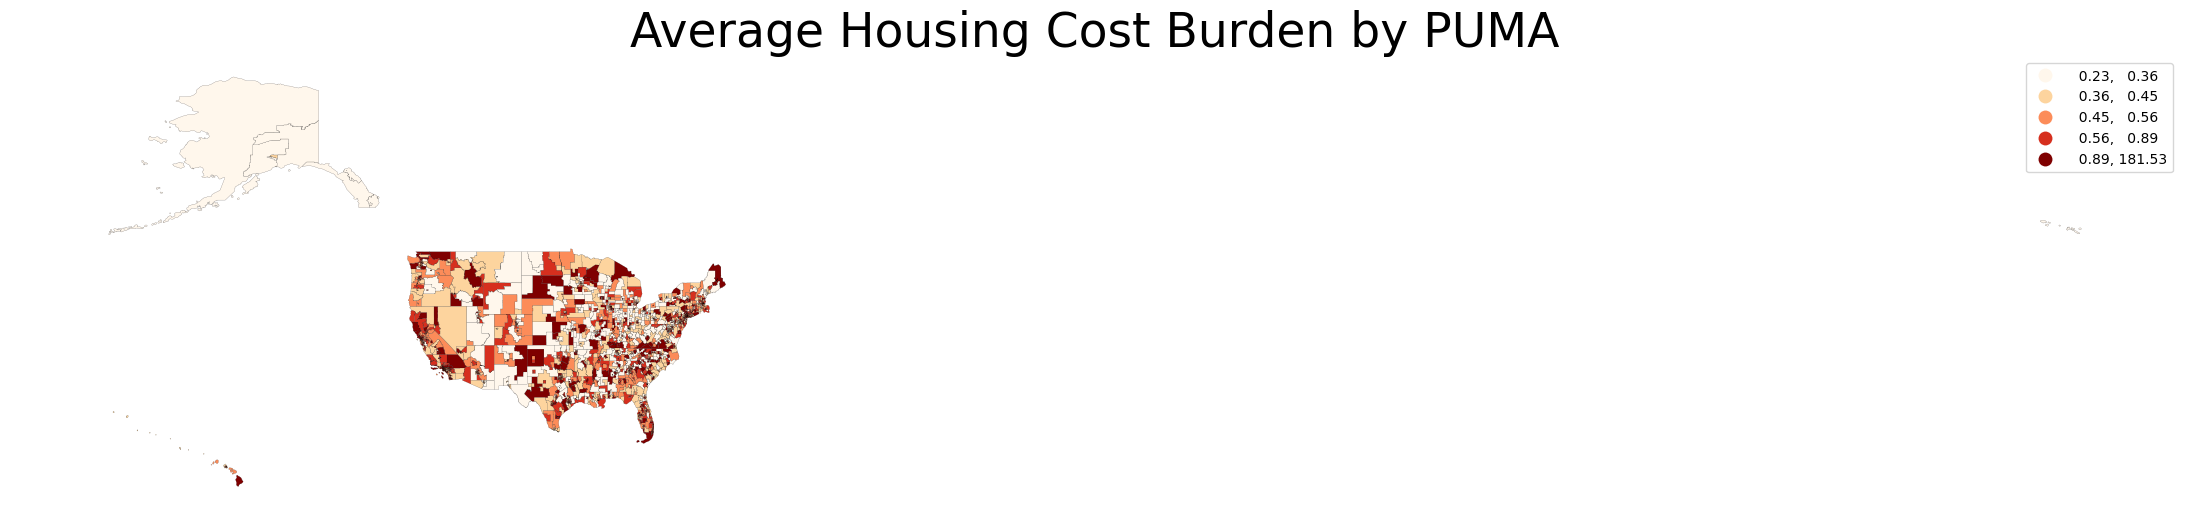

In [9]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Folder containing the extracted Census PUMA shapefile files
shapefile_dir = Path("./puma_shapes")

# Load every state-level 2023 PUMA shapefile
shape_paths = sorted(shapefile_dir.glob("tl_2023_*_puma20.shp"))

if not shape_paths:
    raise FileNotFoundError(
        f"No PUMA shapefiles found in {shapefile_dir.resolve()}. "
        "Extract files like tl_2023_06_puma20.shp into that folder."
    )

frames = [gpd.read_file(path) for path in shape_paths]
puma_shapes = gpd.GeoDataFrame(
    pd.concat(frames, ignore_index=True),
    crs=frames[0].crs,
)

# Match Census shapefile keys to ACS PUMS keys
puma_shapes["STATE"] = puma_shapes["STATEFP20"].astype(int)
puma_shapes["PUMA"] = puma_shapes["PUMACE20"].astype(int)

merged = puma_shapes.merge(weighted, on=["STATE", "PUMA"], how="inner")

ax = merged.plot(
    column="avg_burden",
    cmap="OrRd",
    legend=True,
    figsize=(28, 18),
    scheme="quantiles",
    k=5,
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title("Average Housing Cost Burden by PUMA", fontsize=34)
ax.axis("off")
plt.show()


## Map Severe Housing Burden

Average burden can smooth over extreme cases, so this section maps the share of households in each PUMA that spend more than 50 percent of income on housing. The `0.50` cutoff is a common threshold for severe housing burden and highlights places where affordability stress is especially acute.


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_63363/1904231741.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())


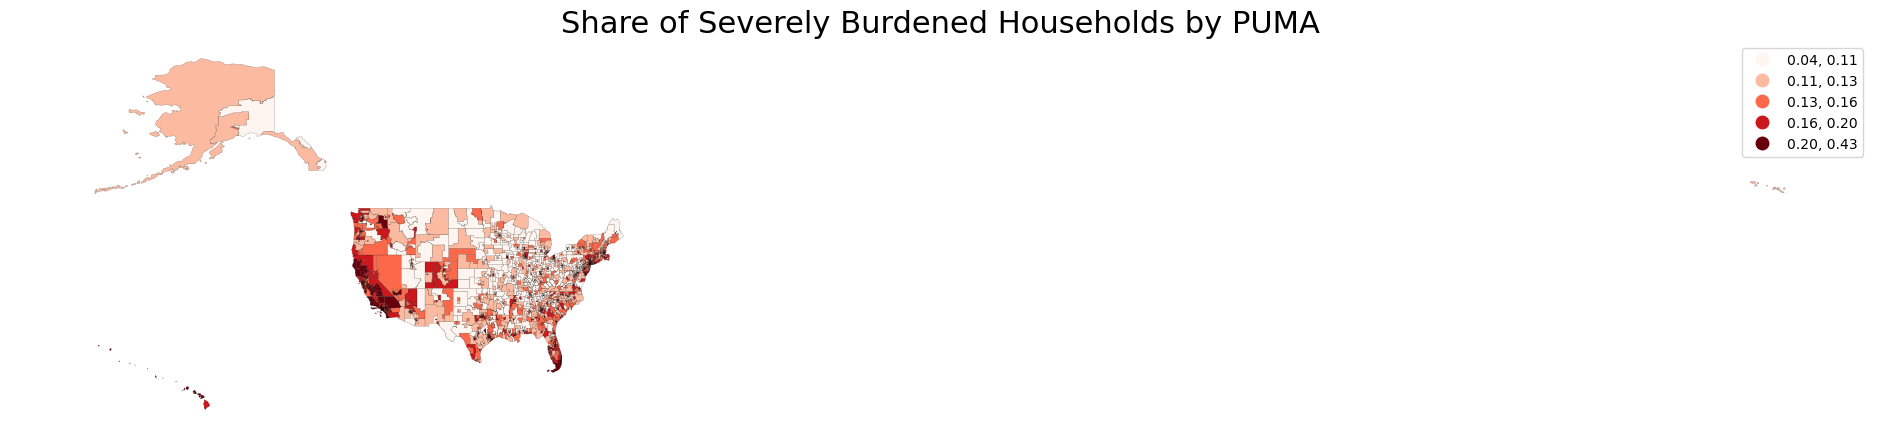

In [10]:
# Share of households with severe housing burden by PUMA
severe_burden = (
    df.assign(severely_burdened=(df["burden_ratio"] > 0.50).astype(int))
    .groupby(["STATE", "PUMA"])
    .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())
    .reset_index(name="severe_burden_rate")
)

severe_map = puma_shapes.merge(severe_burden, on=["STATE", "PUMA"], how="inner")

ax = severe_map.plot(
    column="severe_burden_rate",
    cmap="Reds",
    legend=True,
    figsize=(24, 16),
    scheme="quantiles",
    k=5,
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title("Share of Severely Burdened Households by PUMA", fontsize=22)
ax.axis("off")
plt.show()


## Compare Renters and Owners

This section compares renters and owners using severe burden rates rather than raw average burden ratios. The ACS `TEN` variable distinguishes tenure categories; here, owner-occupied households with and without a mortgage are combined into a single `Owner` group and compared against `Renter` households.


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_63363/1946666418.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())
/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_63363/1946666418.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())


  tenure_group  severe_burden_rate
0        Owner            0.102475
1       Renter            0.258852


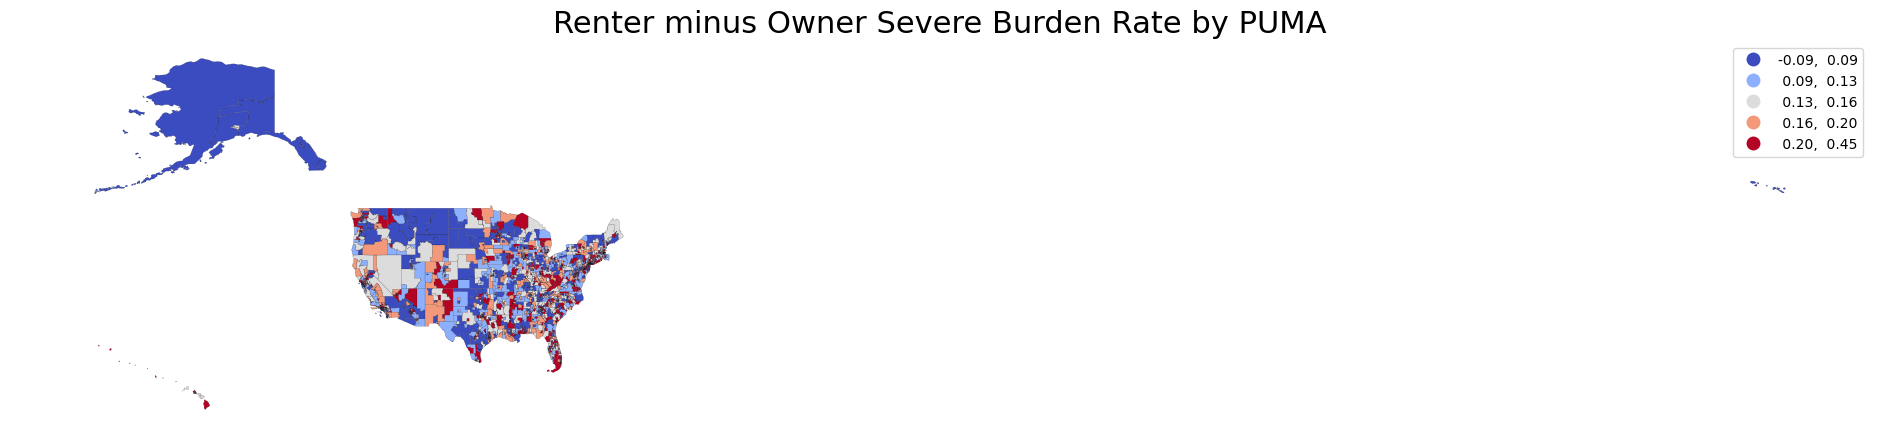

In [11]:
# Compare severe burden rates for renters and owners
tenure_labels = {1: "Owned with mortgage or loan", 2: "Owned free and clear", 3: "Rented", 4: "Occupied without payment of rent"}

tenure_severe = (
    df[df["TEN"].isin([1, 2, 3])]
    .assign(
        tenure_group=lambda x: x["TEN"].map(tenure_labels).replace({
            "Owned with mortgage or loan": "Owner",
            "Owned free and clear": "Owner",
            "Rented": "Renter"
        }),
        severely_burdened=lambda x: (x["burden_ratio"] > 0.50).astype(int)
    )
    .groupby("tenure_group")
    .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())
    .reset_index(name="severe_burden_rate")
)

puma_tenure_severe = (
    df[df["TEN"].isin([1, 2, 3])]
    .assign(
        tenure_group=lambda x: x["TEN"].map(tenure_labels).replace({
            "Owned with mortgage or loan": "Owner",
            "Owned free and clear": "Owner",
            "Rented": "Renter"
        }),
        severely_burdened=lambda x: (x["burden_ratio"] > 0.50).astype(int)
    )
    .groupby(["STATE", "PUMA", "tenure_group"])
    .apply(lambda x: (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum())
    .reset_index(name="severe_burden_rate")
)

print(tenure_severe)

puma_tenure_wide = puma_tenure_severe.pivot(index=["STATE", "PUMA"], columns="tenure_group", values="severe_burden_rate").reset_index()
puma_tenure_wide = puma_tenure_wide.dropna(subset=["Renter", "Owner"])
puma_tenure_wide["renter_owner_gap"] = puma_tenure_wide["Renter"] - puma_tenure_wide["Owner"]

gap_map = puma_shapes.merge(puma_tenure_wide, on=["STATE", "PUMA"], how="inner")

ax = gap_map.plot(
    column="renter_owner_gap",
    cmap="coolwarm",
    legend=True,
    figsize=(24, 16),
    scheme="quantiles",
    k=5,
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title("Renter minus Owner Severe Burden Rate by PUMA", fontsize=22)
ax.axis("off")
plt.show()


## Compare Burden by Tenure

This weighted summary compares average housing burden across ACS tenure categories using household weights (`WGTP`). Weighting matters here because the PUMS microdata are a sample, and simple unweighted means can over- or understate the burden faced by the represented population.


In [12]:
tenure_labels = {1: "Owned with mortgage or loan", 2: "Owned free and clear", 3: "Rented", 4: "Occupied without payment of rent"}

weighted_tenure_burden = (
    df.groupby("TEN")
    .apply(lambda x: (x["burden_ratio"] * x["WGTP"]).sum() / x["WGTP"].sum())
    .reset_index(name="avg_burden")
)

weighted_tenure_burden["tenure_label"] = weighted_tenure_burden["TEN"].map(tenure_labels)
weighted_tenure_burden[["TEN", "tenure_label", "avg_burden"]]


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_63363/2886224193.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["burden_ratio"] * x["WGTP"]).sum() / x["WGTP"].sum())


,TEN,tenure_label,avg_burden
0,1.0,Owned with mortgage or loan,1.142035
1,2.0,Owned free and clear,0.954197
2,3.0,Rented,2.032735


## Regression Modeling

The earlier sections describe where affordability stress appears. This section adds explanatory modeling by predicting both the continuous housing burden ratio and a high-burden indicator using household characteristics such as tenure, household size, building type, and region. These models do not establish causality, but they help identify which variables are most strongly associated with higher burden. To evaluate classification performance more reliably, the notebook also uses stratified cross-validation and ROC-AUC alongside a single train/test split.


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, roc_auc_score
import numpy as np


In [14]:
# Model burden ratio and high burden using household-level predictors
reg_df = df[["burden_ratio", "TEN", "NP", "BLD", "REGION", "TYPEHUGQ", "WGTP"]].copy()
reg_df = reg_df[reg_df["burden_ratio"].notna()].copy()

# Cap extreme burden values so a few very small-income households do not dominate the linear model.
reg_df["burden_ratio_capped"] = reg_df["burden_ratio"].clip(upper=2.0)
reg_df["high_burden"] = (reg_df["burden_ratio"] > 0.30).astype(int)

feature_cols = ["TEN", "NP", "BLD", "REGION", "TYPEHUGQ"]
X = reg_df[feature_cols]
y_reg = reg_df["burden_ratio_capped"]
y_clf = reg_df["high_burden"]
weights = reg_df["WGTP"]

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test, w_train, w_test = train_test_split(
    X, y_reg, y_clf, weights, test_size=0.2, random_state=42, stratify=y_clf
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), ["TEN", "BLD", "REGION", "TYPEHUGQ"]),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), ["NP"])
    ]
)

linear_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

logit_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

logit_balanced_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

linear_model.fit(X_train, y_reg_train, model__sample_weight=w_train)
reg_pred = linear_model.predict(X_test)

logit_model.fit(X_train, y_clf_train, model__sample_weight=w_train)
clf_pred = logit_model.predict(X_test)
clf_prob = logit_model.predict_proba(X_test)[:, 1]

logit_balanced_model.fit(X_train, y_clf_train, model__sample_weight=w_train)
clf_bal_pred = logit_balanced_model.predict(X_test)
clf_bal_prob = logit_balanced_model.predict_proba(X_test)[:, 1]

print("Linear regression results (predicting capped burden ratio)")
print(f"RMSE: {mean_squared_error(y_reg_test, reg_pred, sample_weight=w_test) ** 0.5:.3f}")
print(f"R^2: {r2_score(y_reg_test, reg_pred, sample_weight=w_test):.3f}")
print()
print("Logistic regression results (predicting high burden > 0.30)")
print(f"Accuracy: {accuracy_score(y_clf_test, clf_pred, sample_weight=w_test):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_clf_test, clf_prob, sample_weight=w_test):.3f}")
print(classification_report(y_clf_test, clf_pred, sample_weight=w_test, digits=3))
print()
print("Balanced logistic regression results (predicting high burden > 0.30)")
print(f"Accuracy: {accuracy_score(y_clf_test, clf_bal_pred, sample_weight=w_test):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_clf_test, clf_bal_prob, sample_weight=w_test):.3f}")
print(classification_report(y_clf_test, clf_bal_pred, sample_weight=w_test, digits=3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = {"accuracy": "accuracy", "roc_auc": "roc_auc"}
cv_results = cross_validate(logit_balanced_model, X, y_clf, cv=cv, scoring=cv_scoring, n_jobs=None)

print()
print("Balanced logistic regression cross-validation")
print(f"Mean CV accuracy: {cv_results['test_accuracy'].mean():.3f} +/- {cv_results['test_accuracy'].std():.3f}")
print(f"Mean CV ROC-AUC: {cv_results['test_roc_auc'].mean():.3f} +/- {cv_results['test_roc_auc'].std():.3f}")

feature_names = linear_model.named_steps["preprocess"].get_feature_names_out()
linear_coefs = pd.Series(linear_model.named_steps["model"].coef_, index=feature_names).sort_values(key=np.abs, ascending=False)
logit_coefs = pd.Series(logit_balanced_model.named_steps["model"].coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False)

print("Top linear regression coefficients (largest absolute values)")
display(linear_coefs.head(10).to_frame("coefficient"))
print("Top balanced logistic regression coefficients (largest absolute values)")
display(logit_coefs.head(10).to_frame("coefficient"))


Linear regression results (predicting capped burden ratio)
RMSE: 0.372
R^2: 0.092

Logistic regression results (predicting high burden > 0.30)
Accuracy: 0.696
ROC-AUC: 0.710
              precision    recall  f1-score   support

           0      0.734     0.864     0.794 17456963.0
           1      0.550     0.347     0.425 8367055.0

    accuracy                          0.696 25824018.0
   macro avg      0.642     0.605     0.609 25824018.0
weighted avg      0.674     0.696     0.674 25824018.0


Balanced logistic regression results (predicting high burden > 0.30)
Accuracy: 0.672
ROC-AUC: 0.709
              precision    recall  f1-score   support

           0      0.799     0.687     0.739 17456963.0
           1      0.495     0.639     0.558 8367055.0

    accuracy                          0.672 25824018.0
   macro avg      0.647     0.663     0.648 25824018.0
weighted avg      0.700     0.672     0.680 25824018.0


Balanced logistic regression cross-validation
Mean CV accuracy

,coefficient
cat__TEN_2.0,-0.120181
cat__TEN_3.0,0.115961
cat__BLD_10.0,-0.047576
num__NP,-0.037319
cat__BLD_2.0,-0.026744
cat__REGION_2.0,-0.025724
cat__BLD_9.0,0.024854
cat__REGION_4.0,0.019268
cat__BLD_8.0,0.015900
cat__BLD_4.0,0.013446


Top balanced logistic regression coefficients (largest absolute values)


,coefficient
cat__TEN_3.0,0.864669
cat__TEN_2.0,-0.838315
num__NP,-0.235632
cat__REGION_4.0,0.230938
cat__TYPEHUGQ_1.0,0.192532
cat__REGION_2.0,-0.183541
cat__BLD_2.0,-0.174932
cat__TEN_1.0,0.166179
cat__BLD_1.0,0.085966
cat__BLD_4.0,0.085791


### Interpreting the Regression Results

The linear regression estimates how the selected household characteristics are associated with the capped burden ratio, while the logistic regression estimates how they are associated with the probability of being housing-burdened (`burden_ratio > 0.30`). The coefficients should be read as descriptive associations rather than causal effects. In particular, tenure, building type, and region may proxy for many underlying economic and geographic differences that are not fully observed in the model.

In these results, the linear model has relatively modest explanatory power (`R^2` around `0.09`), which suggests that the included household characteristics explain some variation in burden but leave most of it unexplained. That is not especially surprising, because housing burden is also shaped by many factors not included here, such as local wages, rents, home values, and neighborhood-specific market conditions.

For the classification task, the standard logistic model achieves accuracy around `0.70` with ROC-AUC around `0.71`, which indicates meaningful but not overwhelming separation between burdened and non-burdened households. Its weakness is recall for the high-burden class: the model is much better at identifying households that are not burdened than at catching all households that are burdened.

The balanced logistic specification makes that tradeoff more explicit. Accuracy falls slightly, but recall for the high-burden class rises substantially, which is often preferable when the substantive goal is to detect households under affordability stress rather than simply maximize overall accuracy. The nearly unchanged ROC-AUC suggests that the underlying separability of the classes is similar; what changes is the balance between false positives and false negatives.

The stratified cross-validation results reinforce this interpretation. Mean cross-validated accuracy is about `0.65` and mean ROC-AUC is about `0.72`, with very little variation across folds. That stability suggests the model is capturing a real and fairly consistent signal, even though the overall predictive power remains moderate rather than strong.

The largest coefficients point to tenure as the strongest observed correlate in this specification. Renter status is positively associated with both higher burden ratios and a higher probability of being burdened, while owning free and clear is strongly negatively associated with burden. Household size (`NP`) is also negatively associated with burden in these models, which may reflect the fact that larger households often combine more earners or income sources. Regional and building-type effects appear as smaller but still meaningful correlates, indicating that affordability pressure varies across parts of the country and across housing forms.


## Prepare for K-means Clustering

The clustering section uses K-means to group PUMAs with similar affordability profiles. Because K-means can be sensitive to outliers and feature scaling, the notebook uses more robust PUMA-level summaries and evaluates several cluster counts before choosing a final specification.


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


### Choose the Number of Clusters

K-means requires a choice of `k`, the number of clusters. To avoid choosing that value arbitrarily, the notebook compares candidate cluster counts using both inertia (the elbow method) and silhouette score. Higher silhouette values indicate tighter, better-separated clusters, while the elbow plot shows when adding more clusters yields diminishing returns. In this notebook, `k = 3` is used for the final model because it produces the highest silhouette score and sits near the main elbow in the inertia curve, suggesting a good balance between separation and parsimony.


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_63363/1559475557.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


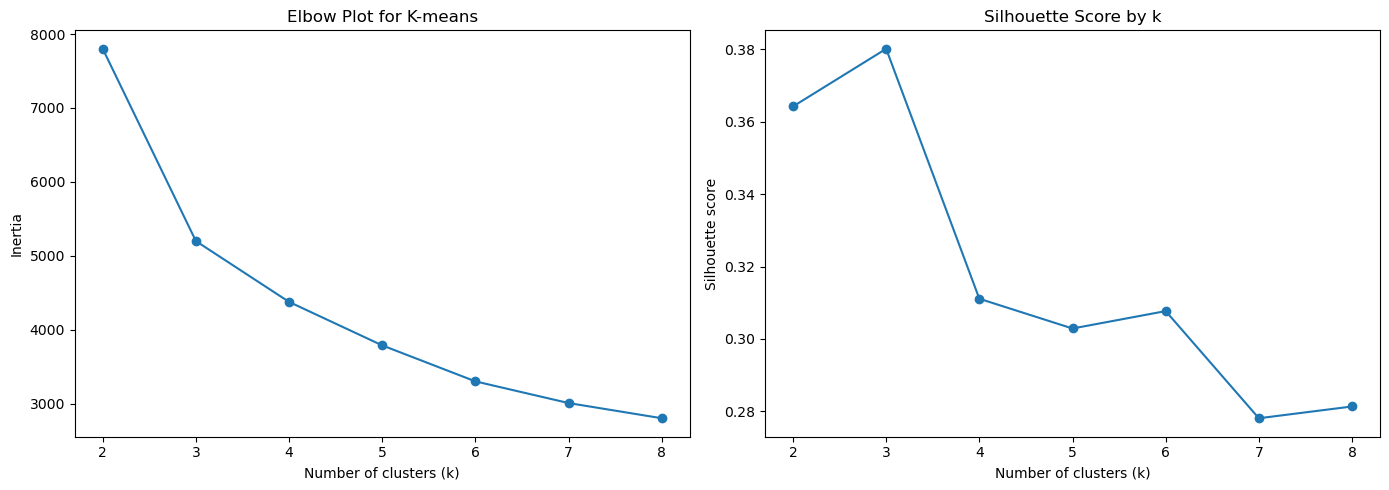

,k,inertia,silhouette_score
0,2,7800.088,0.364
1,3,5198.214,0.380
2,4,4374.933,0.311
3,5,3786.741,0.303
4,6,3299.574,0.308
5,7,3006.348,0.278
6,8,2800.847,0.281


In [16]:
def weighted_median(values, weights):
    values = np.asarray(values)
    weights = np.asarray(weights)
    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values = values[mask]
    weights = weights[mask]
    if len(values) == 0:
        return np.nan
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = weights.cumsum()
    cutoff = weights.sum() / 2
    return values[cumulative >= cutoff][0]

# Build robust PUMA-level features for clustering
cluster_df = (
    df.assign(is_renter=(df["TEN"] == 3).astype(int), severely_burdened=(df["burden_ratio"] > 0.50).astype(int))
    .groupby(["STATE", "PUMA"])
    .apply(lambda x: pd.Series({
        "median_burden": weighted_median(x["burden_ratio_winsorized"], x["WGTP"]),
        "severe_burden_share": (x["severely_burdened"] * x["WGTP"]).sum() / x["WGTP"].sum(),
        "median_income": weighted_median(x["HINCP"], x["WGTP"]),
        "median_monthly_cost": weighted_median(x["monthly_cost"], x["WGTP"]),
        "renter_share": (x["is_renter"] * x["WGTP"]).sum() / x["WGTP"].sum(),
        "weighted_households": x["WGTP"].sum(),
        "sample_households": x["SERIALNO"].count()
    }))
    .reset_index()
)

features = ["median_burden", "severe_burden_share", "median_income", "median_monthly_cost", "renter_share"]
X = cluster_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Elbow Plot for K-means")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), silhouette_scores, marker="o")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(k_values), "inertia": inertias, "silhouette_score": silhouette_scores}).round(3)


## Construct PUMA-Level Features for Clustering

K-means is run on a compact PUMA-level feature table rather than on millions of household rows. To reduce the influence of extreme burden ratios, the clustering inputs use more robust features: weighted median burden, severe-burden share, weighted median income, weighted median monthly cost, and weighted renter share. These choices make the clusters less sensitive to a small number of households with near-zero income. Because K-means depends on the chosen variables and the selected number of clusters, the resulting groups should still be interpreted as descriptive patterns rather than definitive housing-market types.


In [17]:
# Fit final K-means model
# Choose k after inspecting the elbow and silhouette diagnostics above.
final_k = 3
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=20)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)
cluster_summary = (
    cluster_df.groupby("cluster")
    .apply(lambda x: pd.Series({
        "median_burden": np.average(x["median_burden"], weights=x["weighted_households"]),
        "severe_burden_share": np.average(x["severe_burden_share"], weights=x["weighted_households"]),
        "median_income": np.average(x["median_income"], weights=x["weighted_households"]),
        "median_monthly_cost": np.average(x["median_monthly_cost"], weights=x["weighted_households"]),
        "renter_share": np.average(x["renter_share"], weights=x["weighted_households"]),
        "weighted_households": x["weighted_households"].sum(),
        "sample_households": x["sample_households"].sum()
    }))
    .round(3)
)
cluster_summary


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_63363/1931417873.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,median_burden,severe_burden_share,median_income,median_monthly_cost,renter_share,weighted_households,sample_households
cluster,,,,,,,
0,0.215,0.147,125621.756,2213.366,0.296,31285389.0,309077.0
1,0.265,0.223,74302.916,1651.803,0.507,33272364.0,291257.0
2,0.187,0.123,75249.164,1152.464,0.261,64250100.0,709519.0


## Map the K-means Clusters

The final stage joins the cluster labels back to the PUMA boundaries and plots a national map. This reveals which areas share similar affordability profiles, even when they are not geographically adjacent.


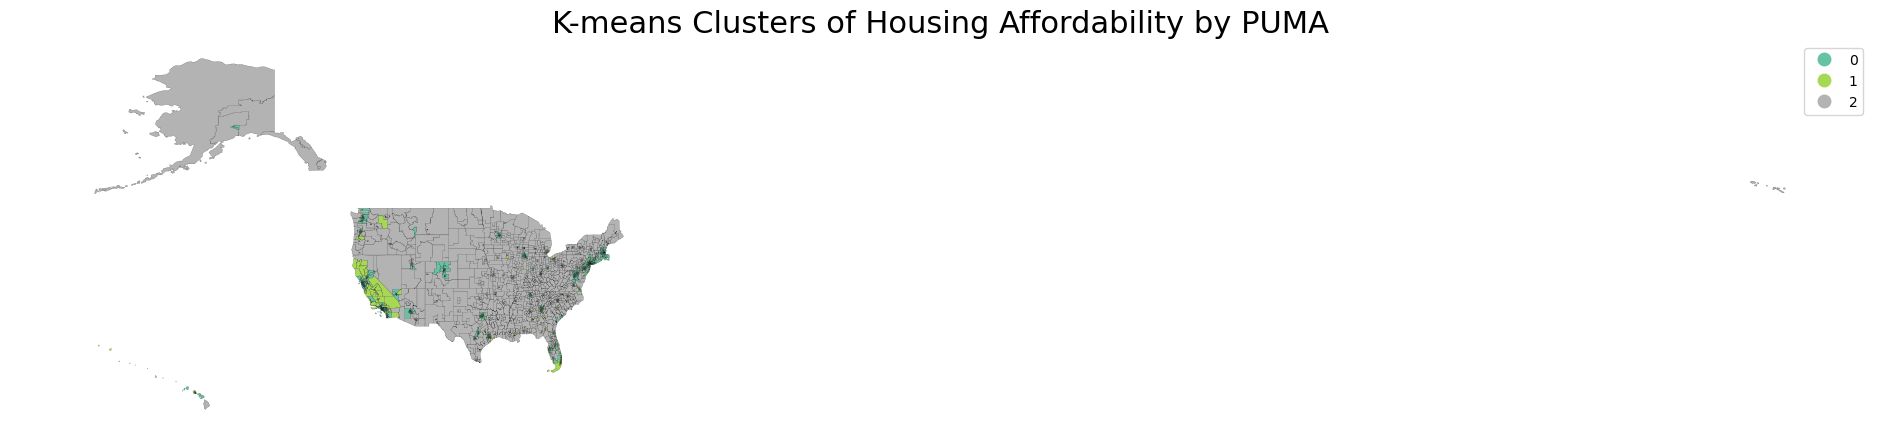

In [18]:
# Join cluster labels back to the PUMA shapes and map them
cluster_map = puma_shapes.merge(cluster_df[["STATE", "PUMA", "cluster"]], on=["STATE", "PUMA"], how="inner")

ax = cluster_map.plot(
    column="cluster",
    cmap="Set2",
    categorical=True,
    legend=True,
    figsize=(24, 16),
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title("K-means Clusters of Housing Affordability by PUMA", fontsize=22)
ax.axis("off")
plt.show()


### Interpreting the Cluster Map

This map shows how the K-means model groups PUMAs with similar housing-market profiles based on median burden, severe-burden share, median income, median monthly housing cost, and renter share. Areas with the same color do not need to be geographically close to one another; instead, they share similar combinations of affordability characteristics.

The numeric cluster labels are arbitrary, so cluster `0` is not inherently better or worse than cluster `1`. The map is most useful when read together with the `cluster_summary` table, which explains what distinguishes each group. With `k = 3`, the clustering emphasizes a smaller set of broad affordability profiles rather than splitting the country into more fragmented groups.


In [19]:
# Build PUMA-level features for clustering
cluster_df = (
    df.assign(is_renter=(df["TEN"] == 3).astype(int))
    .groupby(["STATE", "PUMA"])
    .apply(lambda x: pd.Series({
        "avg_burden": (x["burden_ratio"] * x["WGTP"]).sum() / x["WGTP"].sum(),
        "median_income": x["HINCP"].median(),
        "median_monthly_cost": x["monthly_cost"].median(),
        "renter_share": (x["is_renter"] * x["WGTP"]).sum() / x["WGTP"].sum(),
        "weighted_households": x["WGTP"].sum(),
        "sample_households": x["SERIALNO"].count()
    }))
    .reset_index()
)

# Trim extreme burden values so a few outliers do not dominate K-means.
cluster_df["avg_burden"] = cluster_df["avg_burden"].clip(
    lower=cluster_df["avg_burden"].quantile(0.01),
    upper=cluster_df["avg_burden"].quantile(0.99)
)

features = ["avg_burden", "median_income", "median_monthly_cost", "renter_share"]
X = cluster_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Start with 4 clusters; adjust if you want coarser or finer groupings.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    cluster_df.groupby("cluster")
    .apply(lambda x: pd.Series({
        "avg_burden": np.average(x["avg_burden"], weights=x["weighted_households"]),
        "median_income": np.average(x["median_income"], weights=x["weighted_households"]),
        "median_monthly_cost": np.average(x["median_monthly_cost"], weights=x["weighted_households"]),
        "renter_share": np.average(x["renter_share"], weights=x["weighted_households"]),
        "weighted_households": x["weighted_households"].sum(),
        "sample_households": x["sample_households"].sum()
    }))
    .round(3)
)
cluster_summary


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_63363/1949418496.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_63363/1949418496.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,avg_burden,median_income,median_monthly_cost,renter_share,weighted_households,sample_households
cluster,,,,,,
0,0.735,132305.938,2219.374,0.307,30920933.0,306601.0
1,0.604,76504.936,1121.260,0.259,67132119.0,736225.0
2,0.997,79764.773,1599.701,0.543,27191131.0,231089.0
3,11.118,93840.544,1587.705,0.347,3563670.0,35938.0


## Interpreting the Cluster Summary

The `cluster_summary` table reports the average feature values for each K-means cluster. Each row represents a group of PUMAs with similar housing-market conditions, not a ranking from best to worst.

In general:

- Higher `median_burden` suggests that the typical household in that cluster faces greater housing-cost pressure.
- Higher `severe_burden_share` indicates that a larger share of households spend more than half of income on housing.
- Higher `median_income` indicates more affluent PUMAs.
- Higher `median_monthly_cost` points to more expensive housing markets.
- Higher `renter_share` suggests a larger renter presence in the local housing stock.
- Higher `weighted_households` means the cluster contains more represented households overall.

The numeric cluster labels themselves are arbitrary, so cluster `0` is not inherently better or worse than cluster `1`. A useful next step is to compare clusters descriptively, for example identifying which cluster combines high costs with high incomes versus which cluster combines moderate incomes with high severe-burden rates.


## Conclusion

This analysis uses ACS PUMS housing data to examine housing cost burden across U.S. PUMAs through several complementary approaches. The affordability and severe-burden maps show where housing stress is concentrated geographically, while the renter-versus-owner comparison highlights how burden can differ across tenure groups.

The revised K-means analysis identifies three broad affordability profiles across U.S. PUMAs: a high-cost, high-income group; a higher-stress, renter-heavy group with the greatest burden; and a larger lower-cost, lower-burden group that covers much of the country. This shows that affordability patterns are not defined by cost alone: some places combine high costs with high incomes, while others show elevated burden because housing expenses consume a larger share of more limited household resources.

The regression models extend the analysis from description to association. They suggest that tenure, household size, building type, and region are meaningfully related to housing burden, with tenure emerging as the strongest observed correlate in this specification. At the same time, the relatively modest fit of the linear model indicates that much of the variation in burden is driven by additional local economic and housing-market factors not captured here.

Taken together, the notebook shows that housing affordability is a multidimensional issue shaped by the interaction of income, costs, tenure, and local context. A natural next step would be to incorporate finer geographic controls, compare metro and nonmetro areas, or extend the analysis to policy-relevant outcomes such as severe burden among renters.
